<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
## K-Nearest Neighbor (KNN)

This lesson introduces __KNN__ for **classification** and **regression** tasks, from scratch and using __SKLearn__ library.


### Professor:

 <img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Control and Automation Engineering Department (DECA) <br>
  Institute of Science and Technology of Sorocaba (ICTS) <br>
  São Paulo State University (Unesp) <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

### Table of contents:

1. Iris dataset <br>
$~~~$1.1. Introduction <br>
$~~~$1.2. Loading the dataset <br>
$~~~$1.3. Exploring the dataset <br>
2. KNN classification from scratch <br>
$~~~$2.1. Building a KNN class <br>
$~~~$2.2. Testing the class <br>
$~~~$2.3. Influence of k <br>
$~~~$2.4. Classification evaluation <br>
$~~~$2.3. Classification summary <br>


3. KNN classification with SKLearn <br>
$~~~$3.1. KNN implementation <br>
$~~~$3.2. Influence of the distance criteria <br>

4. KNN Regression with SKLearn <br>
$~~~$4.1. Creating artificial data <br>
$~~~$4.2. Regression implementation and evaluation <br>
 <br>


______

# 1. Iris Dataset

The __Iris dataset__ is a multivariate flowers dataset used and made famous by the British statistician and biologist Ronald Fisher in his 1936 paper "The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis". <br/>

## 1.1. Introduction

Flowers have two types of leaves:

* __Sepals__: the lower, or outermost, part of the flower. They fold over the tender, closed bud and protect it from cold and other injuries
* __Petals__: modified leaves that surround the reproductive parts of flowers. Shaped to increase the flower's attractiveness to insects.

<center><img src="https://drive.google.com/uc?id=1zX76V8RlovZ2OTk-H8UsC50n_cJs51T8" width="800" style="float: left; margin-right: 5px;" border="0px" /></center>

The data set consists of __50 samples from each of three species of Iris__ (__Iris setosa__, __Iris virginica__ and __Iris versicolor__).<br>
__Four features__ were measured from each sample (in centimeters):

* __sepal length__
* __sepal width__
* __petal length__
* __petal width__

Based on the combination of these four features, Fisher originaly developed a linear discriminant model to distinguish each species.



## 1.2. Loading the dataset

Let's load our dataset...

In [3]:
# Load Iris dataset
from sklearn import datasets
import pandas as pd
import numpy as np

dataset = datasets.load_iris()
df = pd.DataFrame(data=np.c_[dataset['data'], dataset['target']],
                    columns=dataset['feature_names'] + ['target'])
if (df.empty == False):
  print ("Dataset loaded sucessfully!")
else:
  print("Error!")

Dataset loaded sucessfully!


## 1.3. Exploring the dataset

Let's explore our dataset in some different ways...

In [5]:
# Inspecting the dataset...
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [6]:
# Checking the data types...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB


Let's check our data in 3D considering only 3 of the 4 available features (dimensions)...

In [8]:
# Plot Iris Dataset in 3D...
import plotly.express as px
from sklearn.datasets import load_iris
import pandas as pd

# Create dataframe
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = [dataset.target_names[i] for i in dataset.target]

# Create 3D iterative graph
fig = px.scatter_3d(df,
                    x='sepal length (cm)',
                    y='sepal width (cm)',
                    z='petal length (cm)',
                    color='species',
                    title='3D Iris Dataset',
                    opacity=0.5)

fig.update_layout(scene_aspectmode='cube')

fig.update_layout(legend=dict(
    orientation="h",
    entrywidth=70,
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))

fig.show()

As we can see, one of the classes (setosa) seems to be easier to classify... <br/>
However, the remaining two classes (versicolor and virginica) are not that easy... <br>
Let's check all 4 dimensions, two by two...

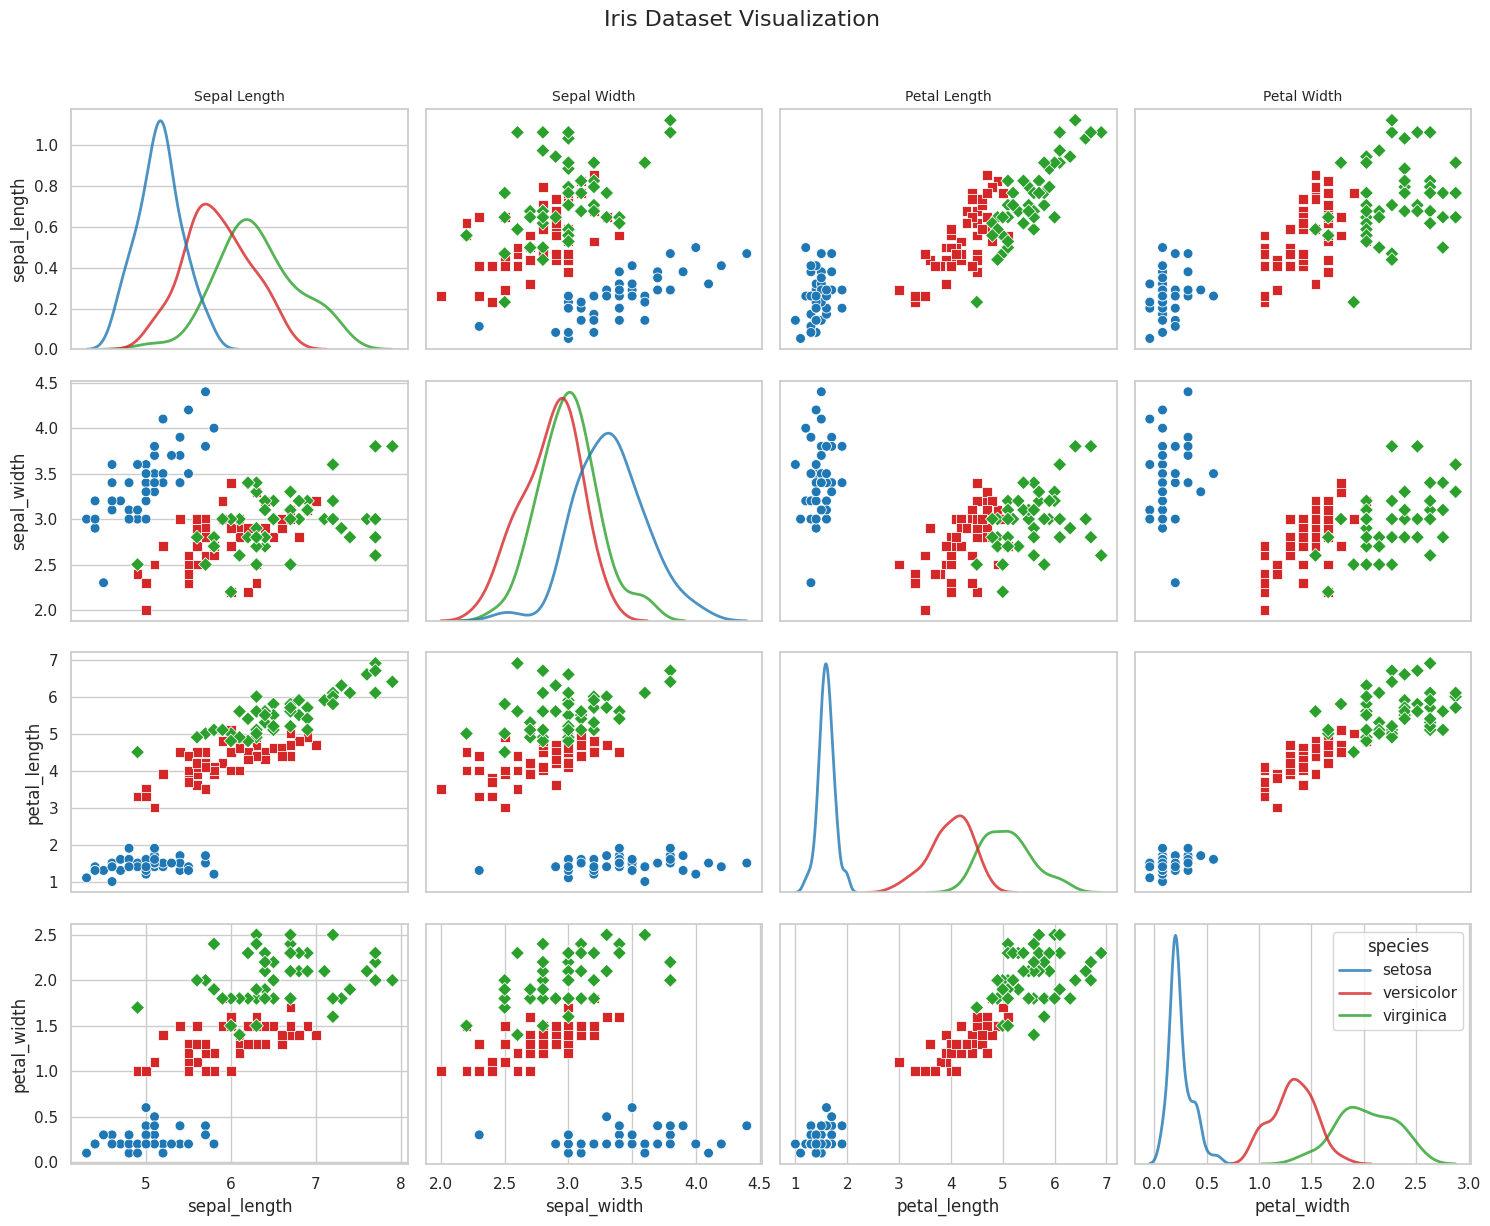

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load Iris dataset
iris = sns.load_dataset('iris')

# Define a color palete (blue, red, green)
custom_palette = ["#1f77b4", "#d62728", "#2ca02c"]
markers = ["o", "s", "D"]  # circle, square, losangle

# Set the visual style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 12))

# List features (dimensions) on the dataset
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
n_features = len(features)

# Create a graphics matrix
for i in range(n_features):
    for j in range(n_features):
        plt.subplot(n_features, n_features, i * n_features + j + 1)

        if i == j:
            # If it's the diagonal, let's plot the density lines...
            plot = sns.kdeplot(data=iris, x=features[i], hue="species",
                             common_norm=False, palette=custom_palette,
                             linewidth=2, alpha=0.8)
            plt.ylabel('sepal_length')
        else:
            # Otherwise, let's show the scallter...
            plot = sns.scatterplot(data=iris, x=features[j], y=features[i],
                                hue="species", palette=custom_palette,
                                style="species", markers=markers, s=50)

        # General configurations
        if i < n_features - 1:
            plt.xlabel('')
            plt.xticks([])
        if j > 0:
            plt.ylabel('')
            plt.yticks([])

        # Insert the title in the first line
        if i == 0:
            plt.title(features[j].replace('_', ' ').title(), fontsize=10)

        # Insert the legend in the last graph
        if i == n_features - 1 and j == n_features - 1:
            # Check if there are elements to the legend
            handles, labels = plot.get_legend_handles_labels()
            if handles:
                plt.legend(handles=handles, labels=labels,
                         bbox_to_anchor=(1.05, 1), loc='upper left', title='Espécie')
        else:
            plt.legend([], [], frameon=False)

plt.suptitle('Iris Dataset Visualization',
             y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 2. KNN from scratch

Let's write our own KNN implementation!
Importing libraries...

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import itertools
from mlxtend.plotting import plot_decision_regions

## 2.1. Building a KNN class

Let's create our KNN class...

In [12]:
class KNN:
    # --------------------------------------------------------------------------
    # K-Nearest Neighbors (KNN) classification algorithm
    # PARAMETERS:
    #    - n_neighbors : int, optional (default=5). Number of neighbors to use
    #      in the majority vote.
    # METHODS:
    #    - euclidean_distance(self, x1, x2): computes the Euclidean distance
    #      between points x1 and x2.
    #    - fit(X_train, y_train): Stores the values of X_train and y_train.
    #    - predict(X): Predicts the class labels for each example in X.
    #    - _predict(x): Predicts the class labels for a single example x in X.
    # --------------------------------------------------------------------------

    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors


    def euclidean_distance(self, x1, x2):
        # ----------------------------------------------------------------------
        # Calculate the Euclidean distance between two data points.
        # Parameters:
        #   - x1 : numpy.ndarray, shape(n_features,).A data point in the dataset
        #   - x2 : numpy.ndarray, shape(n_features,).A data point in the dataset
        # Returns:
        #   - distance : float. The Euclidean distance between x1 and x2.
        # ----------------------------------------------------------------------
        return np.linalg.norm(x1 - x2)


    def fit(self, X_train, y_train):
        # ----------------------------------------------------------------------
        # Stores the values of X_train and y_train.
        # Parameters:
        #    - X_train : numpy.ndarray, shape (n_samples, n_features). The
        #      training dataset.
        #    - y_train : numpy.ndarray, shape (n_samples,). The target labels.
        # ----------------------------------------------------------------------
        self.X_train = X_train
        self.y_train = y_train


    def predict(self, X):
        # ----------------------------------------------------------------------
        # Predicts the class labels for each example in X.
        # Parameters:
        #   - X : numpy.ndarray, shape (n_samples, n_features). The test dataset.
        # Returns:
        #   - predictions : numpy.ndarray, shape (n_samples,). The predicted
        #     class labels for each example in X.
        # ----------------------------------------------------------------------

        # Create empty array to store the predictions
        predictions = []
        # Loop over X examples
        for x in X:
            # Get prediction using the prediction helper function
            prediction = self._predict(x)
            # Append the prediction to the predictions list
            predictions.append(prediction)
        return np.array(predictions)


    def _predict(self, x):
        # ----------------------------------------------------------------------
        # Predicts the class label for a single example.
        # Parameters:
        #   - x : numpy.ndarray, shape (n_features,). A data point in the test dataset.
        # Returns:
        #   - most_occuring_value : int. The predicted class label for x.
        # ----------------------------------------------------------------------

        # Create empty array to store distances
        distances = []
        # Loop over all training examples and compute the distance between x and all the training examples
        for x_train in self.X_train:
            distance = self.euclidean_distance(x, x_train)
            distances.append(distance)
        distances = np.array(distances)

        # Sort by ascendingly distance and return indices of the given n neighbours
        n_neighbors_idxs = np.argsort(distances)[: self.n_neighbors]

        # Get labels of n-neighbour indexes
        labels = self.y_train[n_neighbors_idxs]
        labels = list(labels)
        # Get the most frequent class in the array
        most_occuring_value = max(labels, key=labels.count)
        return most_occuring_value


## 2.2. Testing the class

Let's use our class in our fist classification task...

In [14]:
# KNN CLASSIFICATION

# Checking out some training examples...
print("Example   0: " + str(dataset.data[0]) + " -> " + str(dataset.target[0]))
print("Example  50: " + str(dataset.data[50]) + " -> " + str(dataset.target[50]))
print("Example 100: " + str(dataset.data[100]) + " -> " + str(dataset.target[100]))

# Creating and training model...
model = KNN(4)
model.fit(dataset.data, dataset.target)

# Predicting classes for new instances...
print("New instance 1 prediction -> " + str(model._predict([4.9, 3, 1, 0.01])))
print("New instance 2 prediction -> " + str(model._predict([6, 4, 5, 2])))
print("New instance 3 prediction -> " + str(model._predict([5.5, 3, 4.9, 2.2])))


Example   0: [5.1 3.5 1.4 0.2] -> 0
Example  50: [7.  3.2 4.7 1.4] -> 1
Example 100: [6.3 3.3 6.  2.5] -> 2
New instance 1 prediction -> 0
New instance 2 prediction -> 1
New instance 3 prediction -> 2


## 2.3. Influence of k

Let's investigate the influence of *k* in the classification task... <br>
We will use two distinct approaches:
* For a qualitative analysis, we will use a `plot_decicion_boundary()` function to perform a **visual inspection** of the **decision boundaries** in two dimensions...  
* For a quantitative analysis, we will use a `classification_evaluation()` funcion to compute some of the **classification metrics**...

In [16]:
# ---------------------------------------------------
# Plot decision boundaries for a KNN classifier...
# ---------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
#from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X,Y,classifier,k):

  # Create mesh
  h = 0.1   # Mesh step
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

  # Fazer previsões para cada ponto na malha
  Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  # Configurar cores para as regiões de decisão
  cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA', '#AAFFAA'])
  cmap_bold = ListedColormap(['#0000FF', '#FF0000', '#00FF00'])

  # Plotar as superfícies decisórias
  plt.figure(figsize=(8, 8))
  plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

  # Plotar os pontos de treinamento
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
            edgecolor='k', s=50)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  # Configurar título e rótulos
  plt.title("KNN Decision Boundary (k=" + str(k) + ") in Iris Dataset\n(First two features)", fontsize=14)
  plt.xlabel("Sepal length (standarized)", fontsize=12)
  plt.ylabel("Sepal width (standarized)", fontsize=12)

  # Adicionar legenda
  plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Setosa',
               markerfacecolor='#0000FF', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Versicolor',
               markerfacecolor='#FF0000', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Virginica',
               markerfacecolor='#00FF00', markersize=10)
  ], loc='upper right')

  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()


In [ ]:
# ---------------------------------------------------
# Compute some classification metrics for the KNN classifier...
# ---------------------------------------------------

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

def classification_evaluation(Y,Y_pred):
  accuracy = accuracy_score(Y, Y_pred)
  precision = precision_score(Y, Y_pred, average='micro')
  recall = recall_score(Y, Y_pred, average='micro')
  f1 = f1_score(Y, Y_pred, average='micro')
  print("Accuracy: " + str(accuracy))
  print("Precision: " + str(precision))
  print("Recall: " + str(recall))
  print("F1: " + str(f1))

  # Plot confusion matrix
  cm = confusion_matrix(Y, Y_pred)
  fig, ax = plt.subplots(figsize=(4,3))
  #ax = plt.axes()
  df_cm = cm
  sns.heatmap(df_cm, annot=True, annot_kws={"size": 15}, fmt='d',cmap="Blues", ax = ax )
  ax.set_title('Confusion Matrix')
  plt.show()


## 2.4. Classification evaluation

Now let's evaluate the classifier for some *k*...

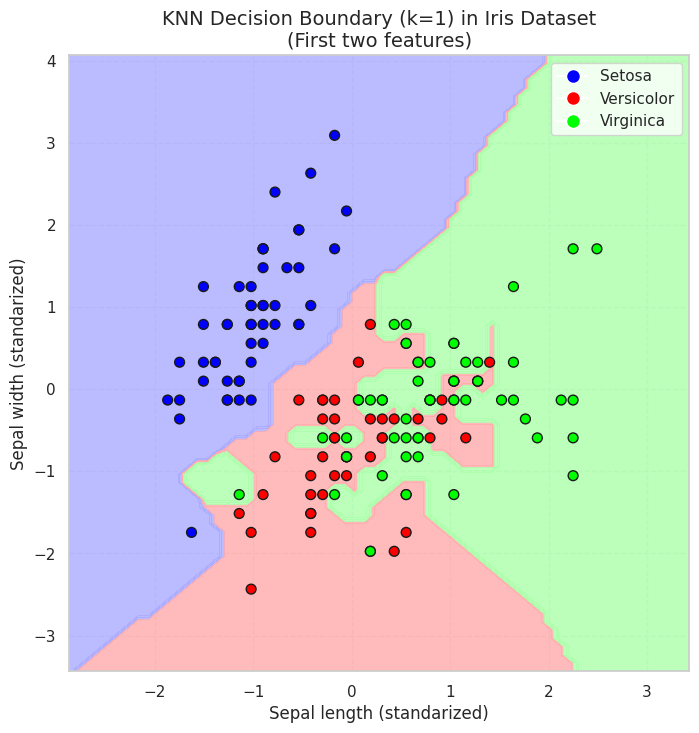

Classification evaluation for k=1


NameError: name 'classification_evaluation' is not defined

In [17]:
# ----------------------------------------------------------
# Classification evaluation
# ----------------------------------------------------------

# Dataset
X = dataset.data[:, :2]  # We will use only the two first features (sepal)
y = dataset.target

# Standarize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = [1,5,10,20,40]

for i, k in enumerate(k_values):

  # Creating KNN classifier
  model1 = KNN(k)
  model1.fit(X_scaled, y)

  # Plot decision boundaries
  plot_decision_boundary(X_scaled,y,model1,k)

  # Evaluate classification
  print("Classification evaluation for k=" + str(k))
  y_pred = model1.predict(X_scaled)
  classification_evaluation(y, y_pred)


## 2.5. Classification summary

As we can see, the quality of the KNN classifier for the training points
* For **small k**:
  * Accuracy is high for the training data (*overfitting*)
  * Boundaries tend to be irregular:
    * Noise is captured by the model
    * A more complex concept is learned
    * The generalization no new data tend to be of poor quality
* For **large k**:
  * Accuracy reduces for the training data (*underfitting*)
  * Boundaries tend to be smooth:
    * Noise is less captured by the model
    * A more general concept is learned
    * The generalization to new data tend to be of high quality


A well known strategy to increase the quality of the model generalization is the **cross validation** (that we will study in next classes...).



# 3. KNN with SKLearn

## 3.1. KNN implementation

Now let's implement a new KNN (with k=1), now using the __SKLearn__ library...

In [18]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=1)
model2.fit(X_scaled,y)
y_pred = model2.predict(X_scaled)
classification_evaluation(y, y_pred)


NameError: name 'classification_evaluation' is not defined

##  3.2. Influence of distance criteria

The SKLearn library has a lot of available distinct __distance criteria__.<br>
Some of them are:

* minkowski (*default*)
$$
  D = \Big( \sum_{i=1}^n {|x_i-y_i|^p} \Big)^{1/p}
$$
* euclidean
$$
  D = \sqrt{ (x_1 - y_1)^2 +(x_2 - y_2)^2 + ... + (x_n - y_n)^2 }
$$
* manhattan
$$
  D = \sum_{i=1}^n {|x_i-y_i|}
$$
* cityblock
$$
  D = { |x_1 - y_1| +|x_2 - y_2| + ... + |x_n - y_n| }
$$
* cosine
$$
  D = \frac{ \sum_{i=1}^n x_i.y_i }{ \sqrt{\sum_{i=1}^n x_i^2} . \sqrt{\sum_{i=1}^n y_i^2}}
$$
* haversine
$$
  D = 2R.arcsin \Big( \sqrt{ sin^2\big(\frac{x_2-x_1}{2}\big) + cos(x_2).sin^2\big( \frac{y2-y1}{2}} \Big)
$$
* chebyshev
$$
  D = max \Big(|x_1-y_1|, |x_2-y_2|) \Big)
$$
* mahalanobis
$$
  D = \sqrt { \Big( (x_1-y_1) \sum^{-1} (x_2 - y_2)^T \Big) }
$$
$$
  \sum =
  \begin{pmatrix}
  \sigma_1^2       & \sigma_{12}  \\
  \sigma_{21}      & \sigma_2^2  \\
  \end{pmatrix}
$$
<center>where: $\sigma_i^2=$ variance and $\sigma_{ij}=$ covaciance.  </center>
$\vdots$



We can specify the distance criterion in our algorithm...

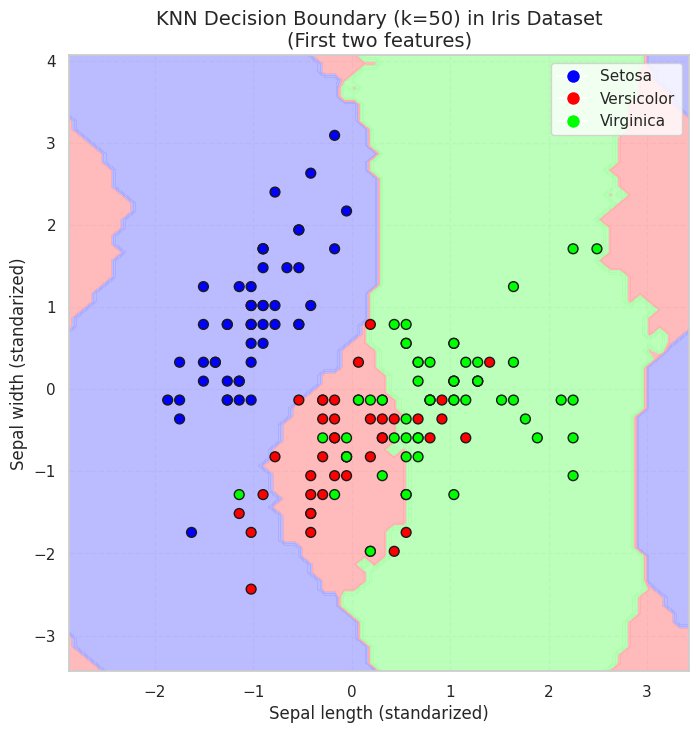

NameError: name 'classification_evaluation' is not defined

In [19]:
# KNN with distinct distance criterion
k=50
model3 = KNeighborsClassifier(n_neighbors=k, metric='haversine')
model3.fit(X_scaled,y)
y_pred = model3.predict(X_scaled)
plot_decision_boundary(X_scaled,y,model3,k)
classification_evaluation(y, y_pred)


# 4. KNN Regression

## 4.1. Creating artificial data

First of all, let's create some artificial data for regression...

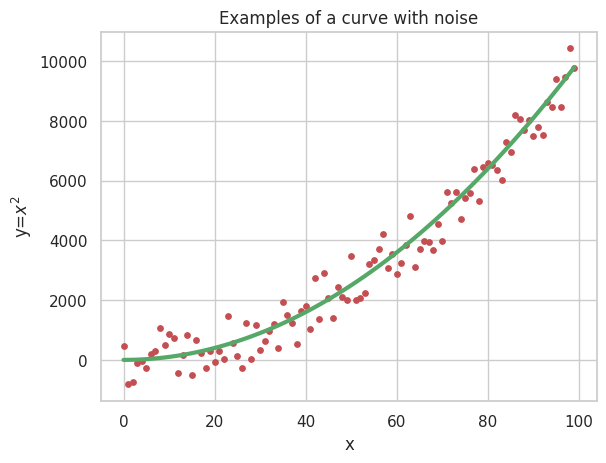

In [20]:
# Creating some artificial points...
import random
import matplotlib.pyplot as plt

x = list(range(0,100, 1))
y = [a**2 for a in x]
y_noise = y.copy()

for index, value in enumerate(x):
  n1 = random.uniform(-1, 1)
  y_noise[index] = y_noise[index] + 1000*n1

plt.xlabel('x')
plt.ylabel('y=$x^2$')
plt.title('Examples of a curve with noise')
plt.rcParams['lines.linewidth'] = 3.0
plt.plot(x,y,'g-')
plt.scatter(x,y_noise, marker='o', color='r', s=15)
plt.show()

## 4.2. Regression implementation and evaluation

Let's create a `regression_evaluation()` function...
This function will:
* Show the predicted value for y (y_pred) for all points in x
* Present values of some metrics with respect to the expected curve $y=x^2$ (green curve)

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

def regression_evaluation(x,y,y_pred):
  # Visual evaluation:
  plt.plot(x,y_pred,'b-', label='k='+str(k))
  plt.legend()
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title('KNN regression for k=' + str(k))
  plt.scatter(x,y_noise, marker='o', color='r', s=15)
  plt.show()
  # Evaluate regression
  print("Regression evaluation for k=" + str(k)+":")
  MAE = sklearn.metrics.mean_absolute_error(y, y_pred)
  print("MAE: ", MAE)
  MSE = sklearn.metrics.mean_squared_error(y, y_pred)
  print("MSE: ", MSE)
  RMSE = sklearn.metrics.root_mean_squared_error(y, y_pred)
  print("RMSE: ", RMSE)
  RAE = np.sum(np.abs(y_pred - y)) / np.sum(np.abs(np.mean(y_pred)-y))
  print("RAE: ", RAE)
  RSE = np.sum(np.pow((y_pred - y),2) / np.sum(np.pow((np.mean(y_pred)-y),2)))
  print("RSE: ", RSE)
  R2 = sklearn.metrics.r2_score(y, y_pred)
  print("R2: ", R2)


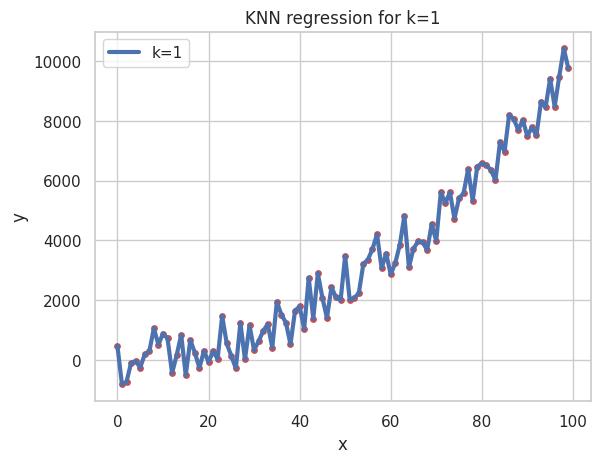

Regression evaluation for k=1:
MAE:  459.56828076503757
MSE:  302343.55905748357
RMSE:  549.857762569088
RAE:  131.24825780552783
RSE:  201.2278877848903
R2:  0.9653353692679603


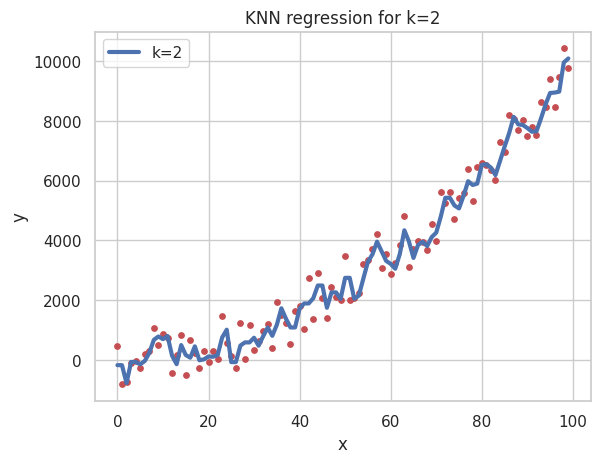

Regression evaluation for k=2:
MAE:  333.2621590304788
MSE:  158785.61346819607
RMSE:  398.47912551123187
RAE:  130.10388473685438
RSE:  197.2932927993951
R2:  0.981794734858602


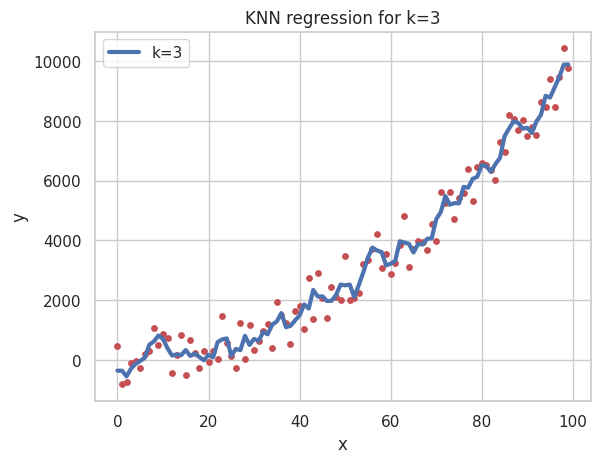

Regression evaluation for k=3:
MAE:  258.66863350618206
MSE:  101193.8220659009
RMSE:  318.1097641788144
RAE:  130.27181946357112
RSE:  198.968135583405
R2:  0.9883978131195735


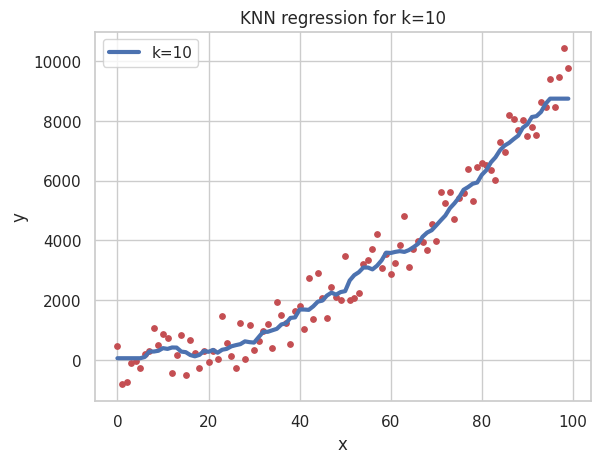

Regression evaluation for k=10:
MAE:  194.74080845648524
MSE:  65121.443976090726
RMSE:  255.1890357677828
RAE:  128.0955681359622
RSE:  191.41505719517596
R2:  0.9925336236194163


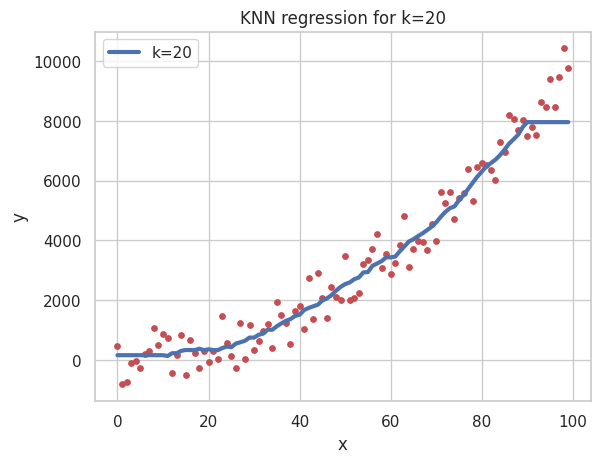

Regression evaluation for k=20:
MAE:  209.21990893425718
MSE:  144829.98767227988
RMSE:  380.5653526955389
RAE:  126.4307781946799
RSE:  184.65066240904588
R2:  0.983394790822612


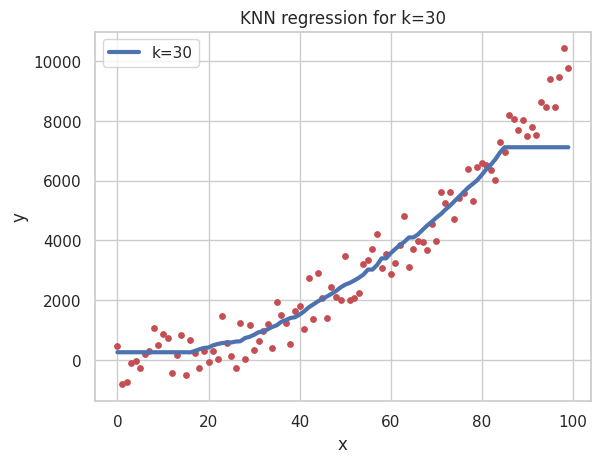

Regression evaluation for k=30:
MAE:  284.9089822903398
MSE:  387008.5727571086
RMSE:  622.1001308126439
RAE:  123.4198977407859
RSE:  173.34139296681707
R2:  0.9556282617477283


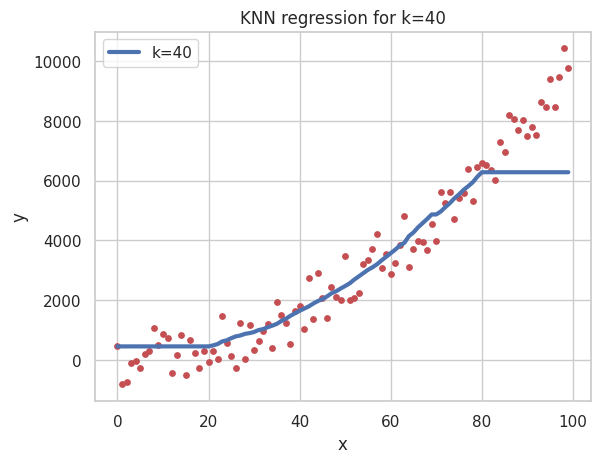

Regression evaluation for k=40:
MAE:  447.1835557637296
MSE:  860673.2171267645
RMSE:  927.7247528910525
RAE:  119.34379767527327
RSE:  159.26990428706375
R2:  0.9013211349841141


In [23]:
# KNN Regression implementation...

from sklearn.neighbors import KNeighborsRegressor
k = 10
# split the wave dataset into a training and a test set
#X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Transform numbers to np
xnp = np.array(x)
xnp = xnp.reshape(100,1)
ynp_noise = np.array(y_noise)
ynp_noise = ynp_noise.reshape(100,1)

# Implement Regression...
k_values = [1,2,3,10,20,30,40]
for k in k_values:
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(xnp,ynp_noise)
  y_pred = knn.predict(xnp)
  regression_evaluation(x,y,y_pred)


## 4.3. Regression summary

* The more k **increases**, the **smoother** the regression
* The KNN regression cannot be implemented on the edges because **there are no k instances available** to perform the voting
* In this case, the error on de edges **impact evaluation metrics**



____
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>

<center>
    <div style="width: 400px;">
        <img src="attachment:image.png" width="500"/>
    </div>
</center>
